In [145]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [147]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper
from model.anfis import ANFIS, SklearnAnfisWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

In [148]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [149]:
from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation
from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke
from torch.utils.data import DataLoader


experiment = CarEvaluation(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]

,Description,Value
0,Session id,199
1,Target,target
2,Target type,Multiclass
3,Original data shape,"(1728, 7)"
4,Transformed data shape,"(1728, 22)"
5,Transformed train set shape,"(1384, 22)"
6,Transformed test set shape,"(344, 22)"
7,Categorical features,6
8,Preprocess,True
9,Imputation type,iterative


False

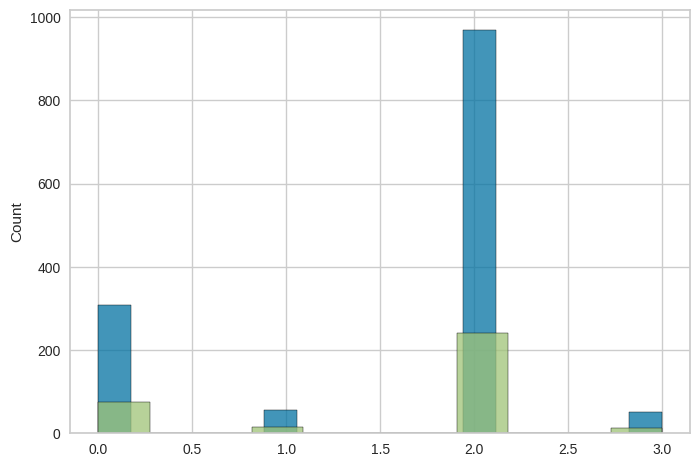

In [150]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [151]:
# prepare the model

from train.early_stop import EarlyStopping

model_params = {
    'type': "litanfis", # anfis, unfis, gift, litanfis
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 3,
    'drop_out_p': 0.3,
    'binary' : binary     
}

model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [152]:
# train

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs, reconstructed, entropy = model(batch_X)
        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler, but ignore the "exceeded total steps" error
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                # Reached the end of the scheduled steps; no further adjustments needed
                pass
            else:
                raise
    
    alpha *= alpha_decaying
    train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    # if early_stopping.early_stop:
    #     print("Early stopping")
    #     break
    
early_stopping.load_best_model(model)

Epoch 1, Train Loss: 0.0140, Val Loss: 1.4243
Epoch 2, Train Loss: 0.0086, Val Loss: 1.3619
Epoch 3, Train Loss: 0.0091, Val Loss: 1.2917
Epoch 4, Train Loss: 0.0072, Val Loss: 1.2115
Epoch 5, Train Loss: 0.0065, Val Loss: 1.1200


KeyboardInterrupt: 

In [ ]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint 

if binary:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]))
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]))
else:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]), multi_class='ovr')
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]), multi_class='ovr')
result = ""

result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(experiment.train_numpy()[1], sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(experiment.test_numpy()[1], sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result PimaDiabetes
------ train ------
              precision    recall  f1-score   support

           0     0.8163    0.9000    0.8561       400
           1     0.7688    0.6215    0.6873       214

    accuracy                         0.8029       614
   macro avg     0.7926    0.7607    0.7717       614
weighted avg     0.7998    0.8029    0.7973       614
AUC	0.8736331775700935
------ test ------
              precision    recall  f1-score   support

           0     0.7727    0.8500    0.8095       100
           1     0.6591    0.5370    0.5918        54

    accuracy                         0.7403       154
   macro avg     0.7159    0.6935    0.7007       154
weighted avg     0.7329    0.7403    0.7332       154
AUC	0.8138888888888889
{'binary': True,
 'drop_out_p': 0.3,
 'in_features': 8,
 'out_features': 2,
 'rules': 3}
{'alpha': 1.0,
 'batch_size': 32,
 'epochs': 100,
 'lr': 0.005,
 'max_lr': 0.01,
 'min_alpha': 0.0,
 'random_state': 199,
 'train_size': 614}


In [ ]:
with open(f'results/{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

<Figure size 1600x1600 with 0 Axes>

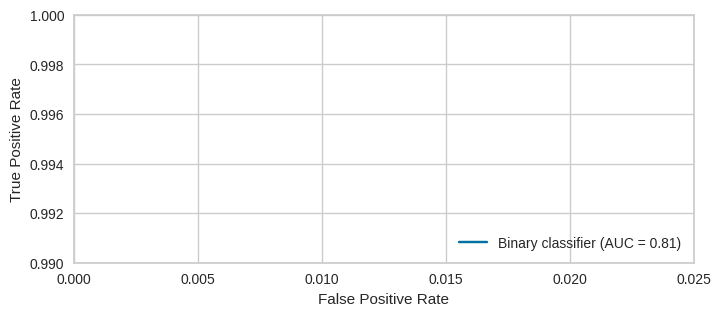

In [ ]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()